## PROBLEM STATEMENT
#### ✈️ Flight Club: Why Is Your Plane Always Late? You have just missed your connecting flight for the third time this year — same airline, same excuse. Fuming at Gate 47, you pull out your laptop and vow revenge through data. You have been handed the full 2015 U.S. flight operation dataset covering millions of flights, delay reasons, airlines, airports, and timestamps. Your mission is to expose the worst offenders, find the safest times to fly, and build a model that tells you exactly how bad your delay is going to be before you even pack your bag.

## OBJECTIVE 1 : 
####   The Reliability Question (Easy) Investigate which airlines actually deliver on their promise of getting you there on time. Think critically about what reliability really means in the data — are delays and cancellations telling the same story, and which carrier would you actually trust for a critical trip?

### Objective 1 Analysis: Airline Reliability
#### Code implementation for on-time performance, delay severity, and consistency

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
possible_paths = ['../data/processed/merged_data.csv']
df = None
for p in possible_paths:
    try:
        df = pd.read_csv(p, low_memory=False)
        print(f'Loaded dataset from: {p}')
        break
    except FileNotFoundError:
        continue

if df is None:
    raise FileNotFoundError('merged_data.csv not found in project root or data/processed/')

# Core fields for Objective 1
df['on_time'] = df['ARRIVAL_DELAY'] <= 15

# Cancellation handling: use available cancellation column, otherwise fallback to zeros
cancel_candidates = ['CANCELLED', 'CANCELED', 'IS_CANCELLED', 'CANCELLED_FLAG', 'CANCELLATION_FLAG']
cancel_col = next((c for c in cancel_candidates if c in df.columns), None)

if cancel_col is not None:
    df['cancellation_flag'] = pd.to_numeric(df[cancel_col], errors='coerce').fillna(0).clip(0, 1)
    print(f'Using cancellation column: {cancel_col}')
else:
    df['cancellation_flag'] = 0.0
    print('No cancellation column found. Using 0.0 for cancellation rate across all airlines.')

airline_metrics = (
    df.groupby('AIRLINE_NAME', as_index=False)
      .agg(
          total_flights=('AIRLINE_NAME', 'size'),
          avg_delay=('ARRIVAL_DELAY', 'mean'),
          on_time_pct=('on_time', lambda s: s.mean() * 100),
          cancellation_pct=('cancellation_flag', lambda s: s.mean() * 100)
      )
      .sort_values('on_time_pct', ascending=False)
      .reset_index(drop=True)
)

airline_metrics[['avg_delay', 'on_time_pct', 'cancellation_pct']] = airline_metrics[['avg_delay', 'on_time_pct', 'cancellation_pct']].round(2)
airline_metrics.sample(10)

Loaded dataset from: ../data/processed/merged_data.csv
Using cancellation column: CANCELLED


,AIRLINE_NAME,total_flights,avg_delay,on_time_pct,cancellation_pct
2,Delta Air Lines Inc.,848662,-0.90,87.21,0.0
9,United Air Lines Inc.,494796,4.34,80.27,0.0
10,American Eagle Airlines Inc.,271633,5.30,79.20,0.0
0,Hawaiian Airlines Inc.,74367,1.58,89.58,0.0
8,Atlantic Southeast Airlines,540959,5.68,81.22,0.0
3,American Airlines Inc.,694938,2.21,82.62,0.0
6,Southwest Airlines Co.,1213765,4.07,81.77,0.0
13,Spirit Air Lines,112338,13.60,71.40,0.0
5,US Airways Inc.,189781,3.32,82.11,0.0
1,Alaska Airlines Inc.,167615,-1.25,87.70,0.0


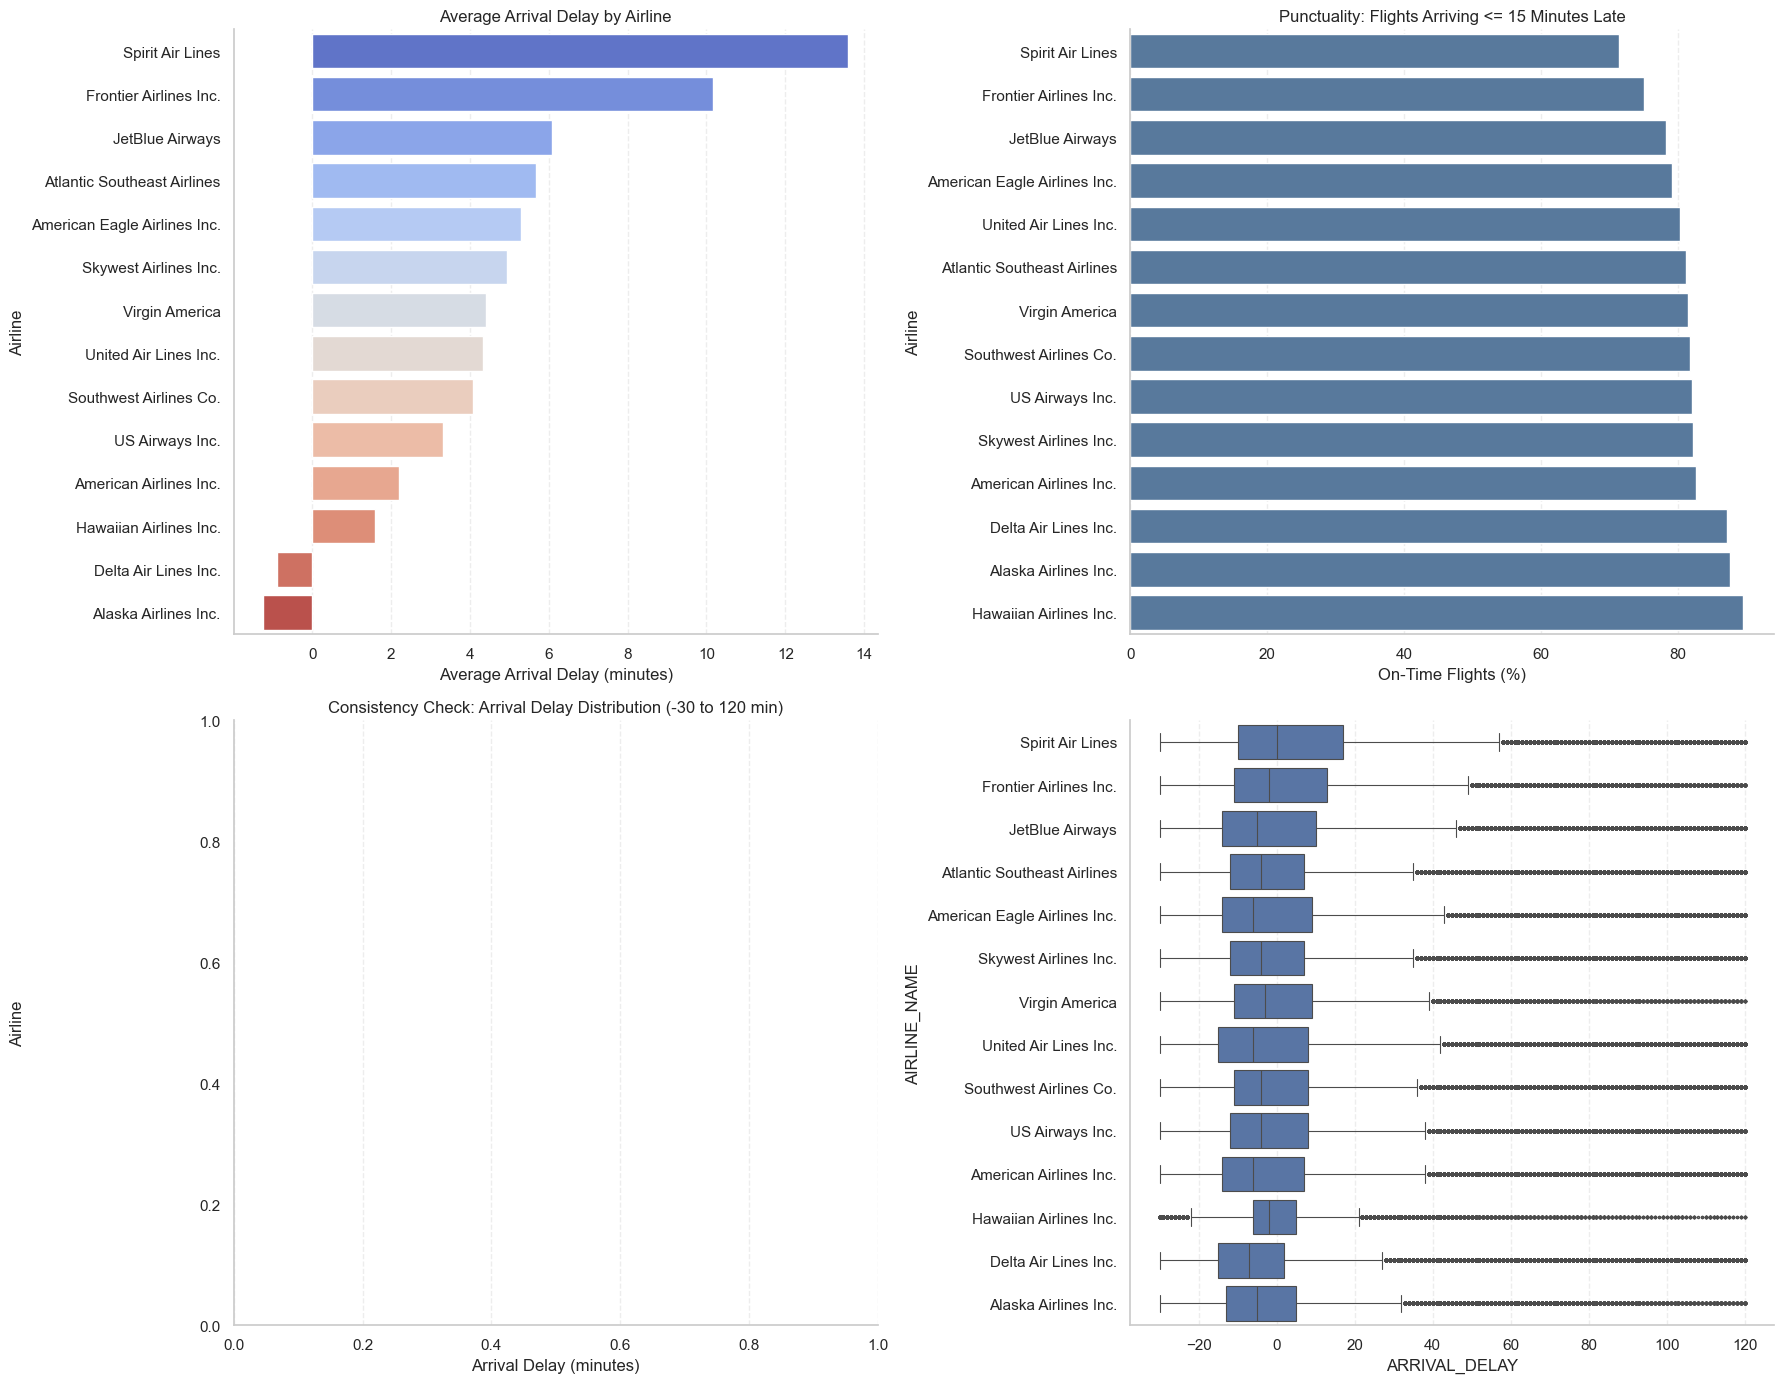

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Theme
sns.set_theme(style="whitegrid")

# Sorting metrics
avg_delay_sorted = airline_metrics.sort_values('avg_delay', ascending=False)
on_time_sorted = airline_metrics.sort_values('on_time_pct', ascending=True)
cancel_sorted = airline_metrics.sort_values('cancellation_pct', ascending=False)

# Filter delays
delay_view = df[df['ARRIVAL_DELAY'].between(-30, 120)].copy()
box_order = avg_delay_sorted['AIRLINE_NAME']

# Create dashboard
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

sns.barplot(
    data=avg_delay_sorted,
    x='avg_delay',
    y='AIRLINE_NAME',
    hue='AIRLINE_NAME',
    palette='coolwarm',
    dodge=False,
    legend=False,
    ax=axes[0, 0]
)

axes[0, 0].set_title('Average Arrival Delay by Airline')
axes[0, 0].set_xlabel('Average Arrival Delay (minutes)')
axes[0, 0].set_ylabel('Airline')


# 2️⃣ On-Time Performance
sns.barplot(
    data=on_time_sorted,
    x='on_time_pct',
    y='AIRLINE_NAME',
    color='#4C78A8',
    ax=axes[0, 1]
)

axes[0, 1].set_title('Punctuality: Flights Arriving ≤ 15 Minutes Late')
axes[0, 1].set_xlabel('On-Time Flights (%)')
axes[0, 1].set_ylabel('Airline')


# 3️⃣ Cancellation Rate (NEW GRAPH)
sns.barplot(
    data=cancel_sorted,
    x='cancellation_pct',
    y='AIRLINE_NAME',
    color='#E45756',
    ax=axes[1, 0]
)

axes[1, 0].set_title('Cancellation Rate by Airline')
axes[1, 0].set_xlabel('Cancellation Rate')
axes[1, 0].set_ylabel('Airline')


# 4️⃣ Delay Distribution
sns.boxplot(
    data=delay_view,
    x='ARRIVAL_DELAY',
    y='AIRLINE_NAME',
    order=box_order,
    orient='h',
    fliersize=1.5,
    linewidth=0.8,
    ax=axes[1, 1]
)

axes[1, 1].set_title('Consistency Check: Arrival Delay Distribution (-30 to 120 min)')
axes[1, 1].set_xlabel('Arrival Delay (minutes)')
axes[1, 1].set_ylabel('Airline')


# Style improvements
for ax in [axes[0,0], axes[0,1], axes[1,0], axes[1,1]]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='x', linestyle='--', alpha=0.35)
    ax.grid(axis='y', visible=False)

plt.tight_layout()
plt.show()

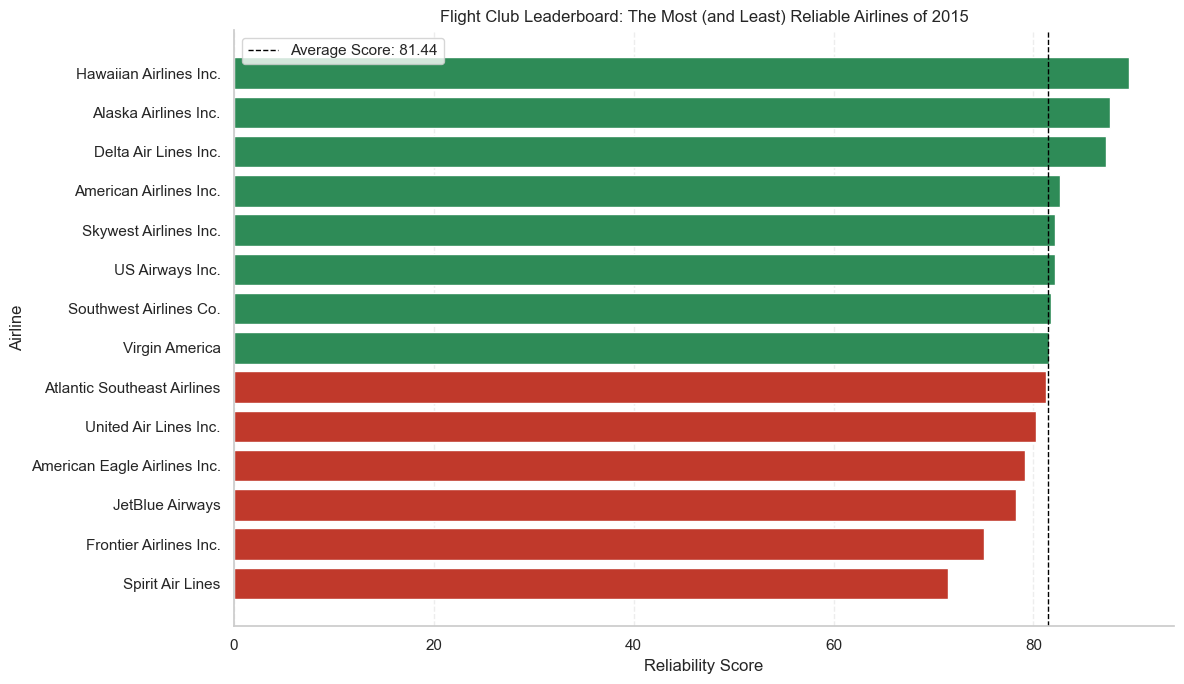

Top 3 most reliable airlines (by reliability score):
          AIRLINE_NAME  on_time_pct  cancellation_pct  reliability_score
Hawaiian Airlines Inc.        89.58               0.0              89.58
  Alaska Airlines Inc.        87.70               0.0              87.70
  Delta Air Lines Inc.        87.21               0.0              87.21

Bottom 3 least reliable airlines (by reliability score):
          AIRLINE_NAME  on_time_pct  cancellation_pct  reliability_score
       JetBlue Airways        78.26               0.0              78.26
Frontier Airlines Inc.        75.06               0.0              75.06
      Spirit Air Lines        71.40               0.0              71.40


In [ ]:
# Final 'Most Reliable' visual using requested weighted score
# Reliability Score = On-Time % - (Cancellation % * 5)
leaderboard = airline_metrics.copy()
leaderboard['reliability_score'] = leaderboard['on_time_pct'] - (leaderboard['cancellation_pct'] * 5)
leaderboard = leaderboard.sort_values('reliability_score', ascending=False).reset_index(drop=True)

avg_score = leaderboard['reliability_score'].mean()
bar_colors = ['#2E8B57' if s > avg_score else '#C0392B' for s in leaderboard['reliability_score']]

plt.figure(figsize=(12, 7))
plt.barh(leaderboard['AIRLINE_NAME'], leaderboard['reliability_score'], color=bar_colors)
plt.gca().invert_yaxis()
plt.axvline(avg_score, color='black', linestyle='--', linewidth=1, label=f'Average Score: {avg_score:.2f}')
plt.title('Flight Club Leaderboard: The Most (and Least) Reliable Airlines of 2015')
plt.xlabel('Reliability Score')
plt.ylabel('Airline')
plt.grid(axis='x', linestyle='--', alpha=0.35)
plt.grid(axis='y', visible=False)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.legend()
plt.tight_layout()
plt.show()

print('Top 3 most reliable airlines (by reliability score):')
print(leaderboard[['AIRLINE_NAME', 'on_time_pct', 'cancellation_pct', 'reliability_score']].head(3).round(2).to_string(index=False))

print('\nBottom 3 least reliable airlines (by reliability score):')
print(leaderboard[['AIRLINE_NAME', 'on_time_pct', 'cancellation_pct', 'reliability_score']].tail(3).round(2).to_string(index=False))

#### The analysis shows that airline performance varies significantly in terms of on-time arrivals and cancellations. Some airlines consistently maintain higher punctuality rates and lower average delays, making them more reliable for passengers. Airlines with better operational efficiency and scheduling practices tend to perform better, while others experience higher delay frequencies. Evaluating both delay duration and cancellation rates helps identify the most dependable airlines for travelers.

